# Homework Chapters 8-9

Numbers correspond to homework problems from [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0FL7W88TM)

Solve problems 55 and 62 from Chapter 8 and problems 64, 70, 73 from Chapter 9 for practice. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

## Chapter 8

55. Implement the bisection method algorithm and solve the equation $\cos(x) = x$ in the range $-5 < x < 5$.


In [2]:
# Solution
f = lambda x: np.cos(x)-x
def bisection(f,a,b,eps=1e-8):
  n=0
  c=(a+b)/2
  while n<1e2 and abs(f(c))>eps:
    n=n+1
    if f(a)*f(c)<0:
      b = c
    else:
      a = c 
    c=(a+b)/2
  return c, n
ans, num_iter = bisection(f,-5,5)
print(f"Found {ans=} after {num_iter} steps.")

Found ans=0.7390851341187954 after 28 steps.


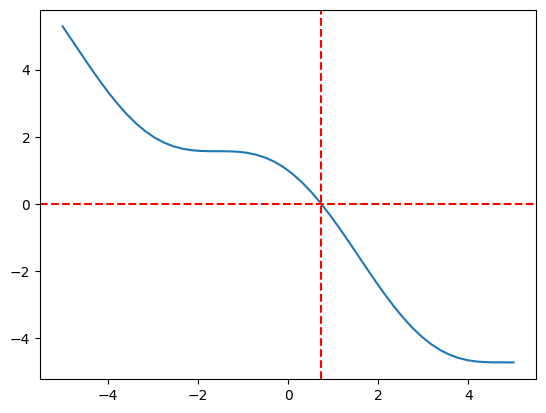

In [3]:
fig,ax=plt.subplots()
x=np.linspace(-5,5)
ax.plot(x,f(x))
ax.axvline(ans,color='red',ls='--')
ax.axhline(0,color='red',ls='--')

62. Compare the number of iterations for the bisection algorithm and the false position algorithm to solve $x^{10} = 2$ in the intervals for $1 < x < 1.1$ and $0 < x < 2$.

In [4]:
# Solution
f  = lambda x: x**10-2
def falsePosition(f,a,b,eps=1e-8):
  n=0
  c=a-(f(a)*(b-a))/(f(b)-f(a))
  while n<1e2 and abs(f(c))>eps:
    n=n+1
    if f(a)*f(c)<0:
      b = c
    else:
      a = c 
    c=a-(f(a)*(b-a))/(f(b)-f(a))
  return c, n
ans, num_iter = falsePosition(f,1,1.1)
print(f"Found {ans=} after {num_iter} steps with False Position.")
ans, num_iter = bisection(f,1,1.1)
print(f"Found {ans=} after {num_iter} steps with Bisection.")

Found ans=1.0717734622946369 after 8 steps with False Position.
Found ans=1.071773462742567 after 26 steps with Bisection.


/var/folders/bz/zk25f6614w5b3_f61czs2dtc0000gr/T/ipykernel_34359/516974286.py:5: RuntimeWarning: invalid value encountered in scalar divide
  c=a-(f(a)*(b-a))/(f(b)-f(a))


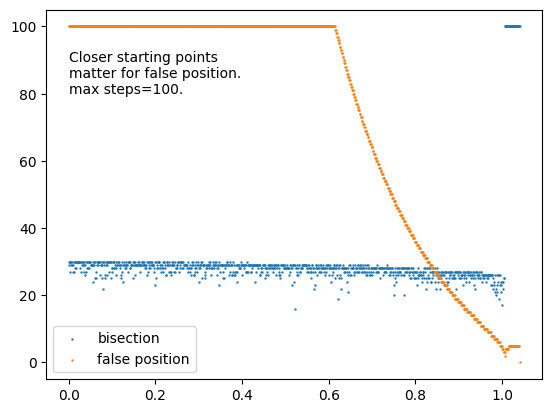

In [5]:
a_vec = np.linspace(0,1.04,1000)
b_vec = np.linspace(2,1.04,1000)
num_fP = []
num_bisec = []
ans_vec = []
for (a,b) in zip(a_vec,b_vec):
  ans,nf = falsePosition(f,a,b)
  ans_vec.append(ans)
  num_fP.append(nf)
  _,nb = bisection(f,a,b)
  num_bisec.append(nb)

fig, ax = plt.subplots()
ax.scatter(a_vec,num_bisec,label="bisection",s=0.5)
ax.scatter(a_vec,num_fP,label="false position",s=0.5)
ax.legend()
ax.text(0,80,"Closer starting points\nmatter for false position.\nmax steps=100.")
plt.show()

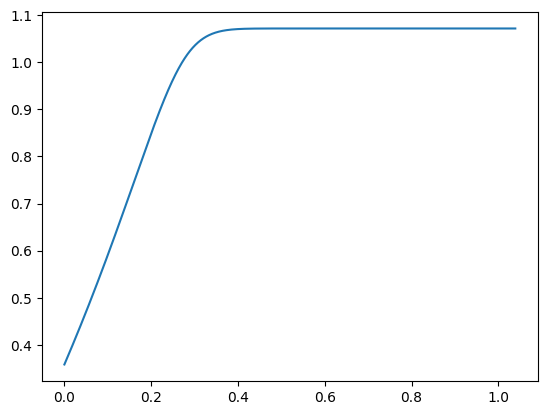

In [6]:
fig, ax = plt.subplots()
ax.plot(a_vec, ans_vec)
plt.show()

## Chapter 9

64. Solve the equation $x^3 = e^{-x}$ using   **(a)** the bisection method,    **(b)** the Newton-Raphson method,  **(c)** discuss the convergence speed of both implementations.

In [7]:
# Solution
f = lambda x: x**3 - np.exp(-x)
bisection(f,0,1)

(0.7728829607367516, 26)

In [8]:
def newtonRaphson(f,df,x0,eps=1e-8):
  n=0
  while abs(f(x0))>eps:
    n=n+1
    x0 = x0-f(x0)/df(x0)
  return x0, n

In [9]:
df = lambda x: 3*x**2 + np.exp(-x)
newtonRaphson(f,df,1)

(np.float64(0.7728829591522018), 4)

## DISCUSSION

Newton Raphson takes 4 steps and the bisection method takes 26 steps. Since the Newton Raphson method relies on the derivative, it can use the slope and get to the root much faster.

70. Solve the following three sets of systems of equations for each of the three unknowns (Note: some boundary problems can sometimes be stated in the form of multiple equations.) **(a)** $x^2 + y^2 + z^2 = 1$; $e^x + yz = 2$; $\sin(x) + \cos(y)  = -z$    **(b)** $\ln(x) + y^3 - z = 4$; $x^2 - \tan(y) + z^2 = 3$; $xy + e^z = 1$    **(c)** $x^3 + y^3 + z^3 = 6$; $\sqrt{x} + \sqrt{y} + \sqrt{z} = 3$; $\sin(xy) = \cos(z)$ 

In [10]:
# Solution
def f(r):
  x,y,z = r
  dx = x**2+y**2+z**2-1
  dy = np.sin(x) + np.cos(y) - z
  dz = np.exp(-x) + y*z - 2
  return [dx,dy,dz]
x,y,z = fsolve(f,[-0.3,0.2,0.4])
print(f"The solutions are: {x=},{y=},{z=}. Check: is {x**2 + y**2 + z**2}=1?")
x,y,z = fsolve(f,[0.3,-0.2,-0.4])
print(f"The solutions are: {x=},{y=},{z=}. Check: is {x**2 + y**2 + z**2}=1?")

The solutions are: x=np.float64(-0.6434118333381544),y=np.float64(0.7546432946002826),z=np.float64(0.12858736576886043). Check: is 1.0000000000001084=1?
The solutions are: x=np.float64(-0.7309496936189663),y=np.float64(-0.6727516232142173),z=np.float64(0.11453295971487654). Check: is 1.0000000000000746=1?


In [11]:
# Solution
def f(r):
  x,y,z = r
  dx = np.log(x) + y**3 - z -4
  dy = x**2 - np.tan(y) + z**2 - 3
  dz = x*y + np.exp(z) - 1
  return [dx,dy,dz]
print(f"One solution is {fsolve(f,[3,0.2,0.4])}")


One solution is [ 0.72133175  1.25445309 -2.35258281]


**(c)** $x^3 + y^3 + z^3 = 6$; $\sqrt{x} + \sqrt{y} + \sqrt{z} = 3$; $\sin(xy) - \cos(z) = 0$ 

In [12]:
# Solution
def f(r):
  x,y,z = r
  dx = x**3 + y**3 + z**3 - 6
  dy = np.sqrt(x) + np.sqrt(y) + np.sqrt(z) - 3
  dz = np.sin(x*y) - np.cos(z)
  return [dx,dy,dz]
print(f"One solution is {fsolve(f,[1.2,2,1.2])}")

One solution is [1.22886861 1.59835657 0.39337389]


73. **(P)** From quantum mechanics - [Schwindt: Conceptual Quantum Mechanics (2016) (p.153)], a bound state submersed in a quantum well $V_0$ for $x \in (-x_0,+x_0)$ with $y\equiv kx$, where the particle's energy is $E=V_0 + \frac{\hbar^2}{2m}k^2$, we find the solution for $k$ by solving the non-linear equation $y \tan y = \sqrt{x^2 |U_0| - y^2}$ with  $U_0 \equiv \frac{2m}{\hbar^2}V_0$.    **(a)** find multiple solutions for $y$   **(b)** similar to the Figure from class, find the solution graphically; plot $\tan y$ and the second part of the equation and look for the overlapping points. 

/var/folders/bz/zk25f6614w5b3_f61czs2dtc0000gr/T/ipykernel_34359/2877894809.py:6: RuntimeWarning: invalid value encountered in sqrt
  f_right = lambda y,A: np.sqrt(A-y**2)


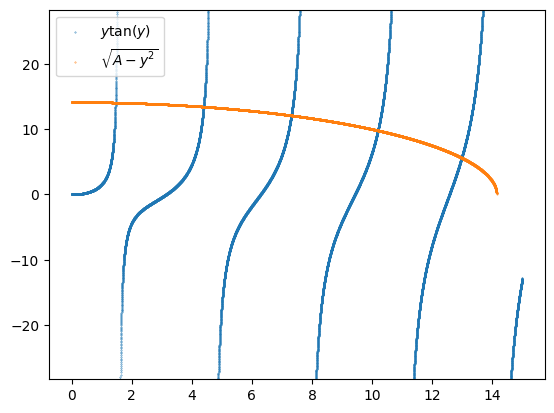

{np.float64(1.466885),
 np.float64(4.396287),
 np.float64(7.310704),
 np.float64(10.190899),
 np.float64(12.975417)}

In [13]:
# Solution
A=200
fig, ax= plt.subplots()
x = np.linspace(0,15,20000)
f_left = lambda y: y*np.tan(y)
f_right = lambda y,A: np.sqrt(A-y**2)
f = lambda y: y*np.tan(y)-np.sqrt(A-y**2)
ax.scatter(x,f_left(x), label=r"$y \tan(y)$", s=0.1)
ax.scatter(x,f_right(x,A), label=r"$\sqrt{A-y^2}$", s=0.1)
ax.set_ylim(-2*np.sqrt(A), 2*np.sqrt(A))
ax.legend()
plt.show()

max_val = 14
guess_sol = np.linspace(1,max_val,100)
my_sol=[]
for x0 in guess_sol:
  x1 = fsolve(f,x0)[0]
  if x1<max_val:
    my_sol.append(round(x1,6))
set(list(my_sol))